In [14]:
# ================================
# Core Libraries
# ================================
import pandas as pd
import numpy as np

# ================================
# Machine Learning
# ================================
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ================================
# Model Saving
# ================================
import joblib

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# ================================
# Load Dataset
# ================================
df = pd.read_csv("/Applications/DataScienceInProduction/data/transactions.csv")

print("Shape:", df.shape)
df.head()

Shape: (299695, 17)


,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


In [3]:
# Dataset Structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           299695 non-null  int64  
 1   user_id                  299695 non-null  int64  
 2   account_age_days         299695 non-null  int64  
 3   total_transactions_user  299695 non-null  int64  
 4   avg_amount_user          299695 non-null  float64
 5   amount                   299695 non-null  float64
 6   country                  299695 non-null  str    
 7   bin_country              299695 non-null  str    
 8   channel                  299695 non-null  str    
 9   merchant_category        299695 non-null  str    
 10  promo_used               299695 non-null  int64  
 11  avs_match                299695 non-null  int64  
 12  cvv_result               299695 non-null  int64  
 13  three_ds_flag            299695 non-null  int64  
 14  transaction_tim

In [4]:
# List all column names
df.columns

Index(['transaction_id', 'user_id', 'account_age_days',
       'total_transactions_user', 'avg_amount_user', 'amount', 'country',
       'bin_country', 'channel', 'merchant_category', 'promo_used',
       'avs_match', 'cvv_result', 'three_ds_flag', 'transaction_time',
       'shipping_distance_km', 'is_fraud'],
      dtype='str')

In [5]:
# Statistical summary
df.describe()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud
count,299695.0000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000
mean,149848.0000,3002.559432,973.397871,50.673321,148.142973,177.165279,0.153640,0.837999,0.872110,0.784588,357.049028,0.022062
std,86514.6388,1732.309663,525.241409,5.976391,200.364624,306.926507,0.360603,0.368453,0.333968,0.411109,427.672074,0.146887
min,1.0000,1.000000,1.000000,40.000000,3.520000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,74924.5000,1501.000000,516.000000,46.000000,46.190000,42.100000,0.000000,1.000000,1.000000,1.000000,136.600000,0.000000
50%,149848.0000,3007.000000,975.000000,51.000000,90.130000,89.990000,0.000000,1.000000,1.000000,1.000000,273.020000,0.000000
75%,224771.5000,4504.000000,1425.000000,56.000000,173.450000,191.110000,0.000000,1.000000,1.000000,1.000000,409.180000,0.000000
max,299695.0000,6000.000000,1890.000000,60.000000,4565.290000,16994.740000,1.000000,1.000000,1.000000,1.000000,3748.560000,1.000000


In [6]:
# ==============================
# Missing Values Check
# ==============================
df.isnull().sum()

transaction_id             0
user_id                    0
account_age_days           0
total_transactions_user    0
avg_amount_user            0
amount                     0
country                    0
bin_country                0
channel                    0
merchant_category          0
promo_used                 0
avs_match                  0
cvv_result                 0
three_ds_flag              0
transaction_time           0
shipping_distance_km       0
is_fraud                   0
dtype: int64

In [7]:
# ==============================
# Fraud vs Normal Transactions
# ==============================
df['is_fraud'].value_counts()

is_fraud
0    293083
1      6612
Name: count, dtype: int64

In [8]:
df['is_fraud'].value_counts(normalize=True) * 100

is_fraud
0    97.793757
1     2.206243
Name: proportion, dtype: float64

# Normal Transactions are 97.79% 
# Fraud Transactions are 2.21%

In [12]:
# Average amount by fraud status
df.groupby("is_fraud")["amount"].mean()

is_fraud
0    167.829976
1    590.961199
Name: amount, dtype: float64

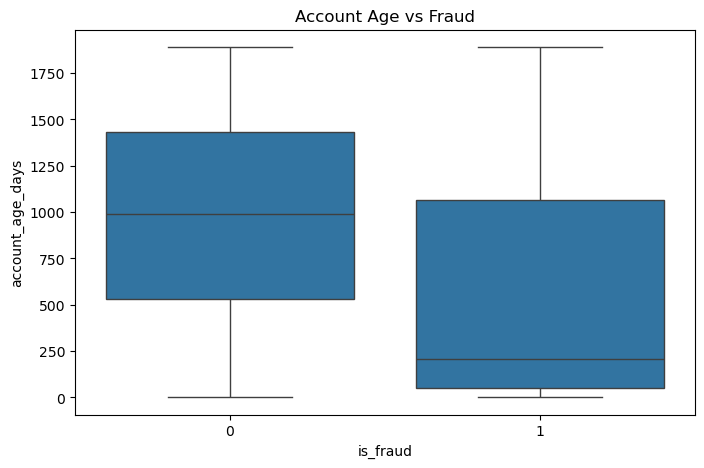

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x="is_fraud", y="account_age_days", data=df)
plt.title("Account Age vs Fraud")
plt.show()

In [16]:
df.groupby("is_fraud")["shipping_distance_km"].mean()

is_fraud
0     339.704956
1    1125.841016
Name: shipping_distance_km, dtype: float64

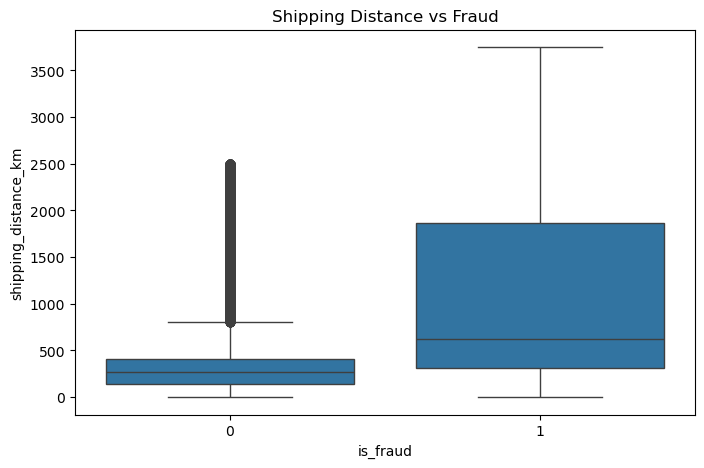

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x="is_fraud", y="shipping_distance_km", data=df)
plt.title("Shipping Distance vs Fraud")
plt.show()

In [18]:
df.groupby("is_fraud")["avs_match"].mean()

is_fraud
0    0.850356
1    0.290230
Name: avs_match, dtype: float64

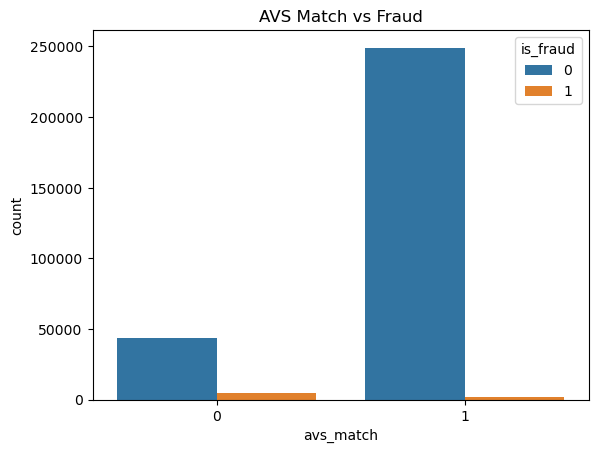

In [19]:
sns.countplot(x="avs_match", hue="is_fraud", data=df)
plt.title("AVS Match vs Fraud")
plt.show()

In [20]:
df.groupby("is_fraud")["cvv_result"].mean()

is_fraud
0    0.883095
1    0.385209
Name: cvv_result, dtype: float64

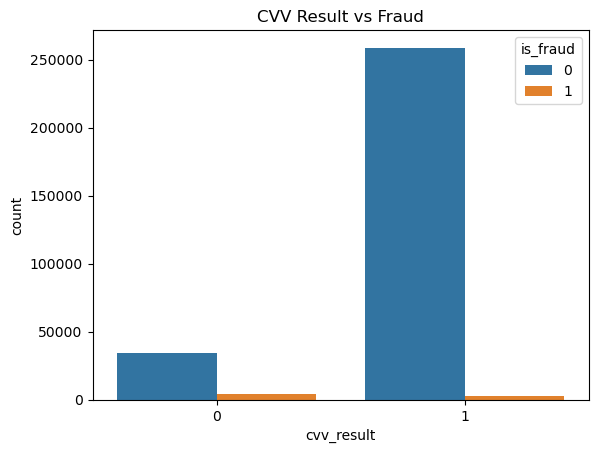

In [21]:
sns.countplot(x="cvv_result", hue="is_fraud", data=df)
plt.title("CVV Result vs Fraud")
plt.show()

In [22]:
df.groupby("is_fraud")["three_ds_flag"].mean()

is_fraud
0    0.794601
1    0.340744
Name: three_ds_flag, dtype: float64

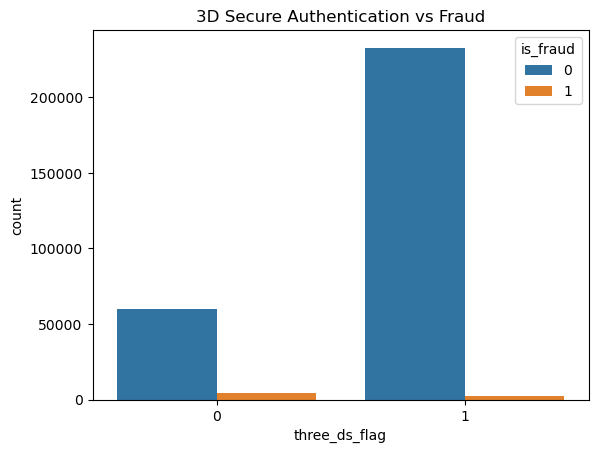

In [23]:
sns.countplot(x="three_ds_flag", hue="is_fraud", data=df)
plt.title("3D Secure Authentication vs Fraud")
plt.show()

In [24]:
df.groupby("is_fraud")["total_transactions_user"].mean()

is_fraud
0    50.688665
1    49.993194
Name: total_transactions_user, dtype: float64

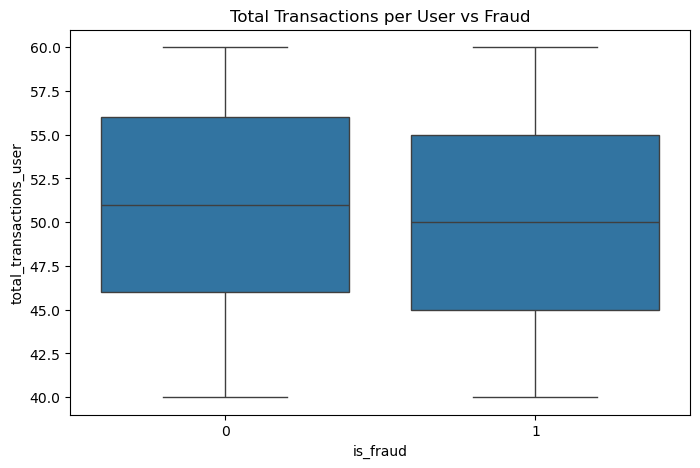

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x="is_fraud", y="total_transactions_user", data=df)
plt.title("Total Transactions per User vs Fraud")
plt.show()

In [26]:
df.groupby("is_fraud")["avg_amount_user"].mean()

is_fraud
0    148.180170
1    146.494155
Name: avg_amount_user, dtype: float64

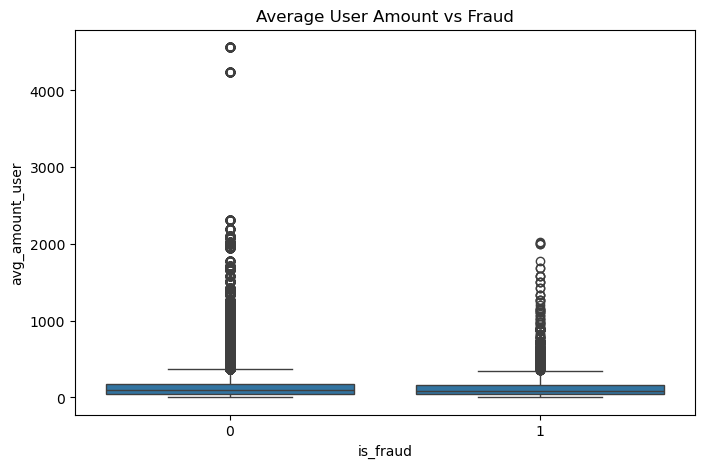

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x="is_fraud", y="avg_amount_user", data=df)
plt.title("Average User Amount vs Fraud")
plt.show()

In [28]:
df.groupby("country")["is_fraud"].mean().sort_values(ascending=False)

country
TR    0.028031
RO    0.024033
PL    0.023394
ES    0.023126
US    0.023065
FR    0.021883
IT    0.021213
GB    0.021175
NL    0.017836
DE    0.016690
Name: is_fraud, dtype: float64

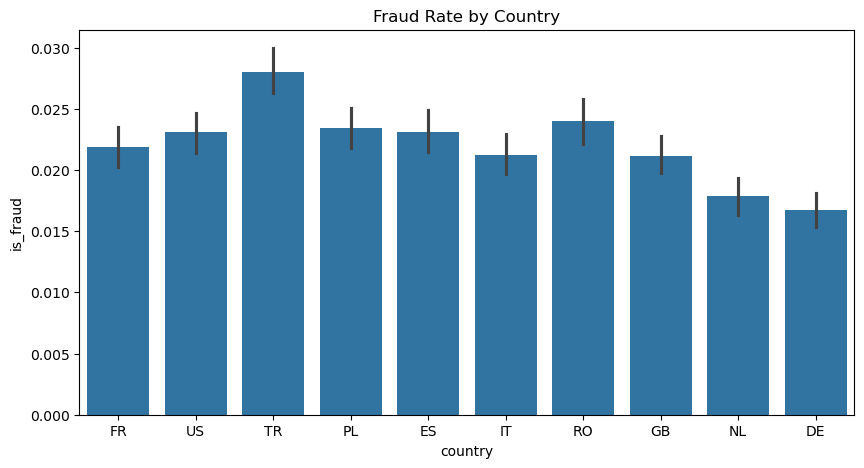

In [29]:
plt.figure(figsize=(10,5))
sns.barplot(x="country", y="is_fraud", data=df)
plt.title("Fraud Rate by Country")
plt.show()

In [30]:
df["transaction_time"] = pd.to_datetime(df["transaction_time"])

In [31]:
df["transaction_hour"] = df["transaction_time"].dt.hour
df["transaction_day"] = df["transaction_time"].dt.dayofweek

In [32]:
df = df.drop("transaction_time", axis=1)

In [33]:
df["amount_ratio"] = df["amount"] / df["avg_amount_user"]

In [34]:
# ======================================
# Ensure raw datetime column is removed
# ======================================
if "transaction_time" in df.columns:
    df = df.drop("transaction_time", axis=1)

In [35]:
# ======================================
# Drop ID columns (not useful for ML)
# ======================================
df = df.drop(["transaction_id", "user_id"], axis=1)

In [36]:
# ======================================
# Define Features and Target
# ======================================
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

print(X.shape, y.shape)

(299695, 16) (299695,)


In [37]:
# ======================================
# Train Test Split
# ======================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (239756, 16)
Test shape: (59939, 16)


In [38]:
# ======================================
# Identify Numerical and Categorical Columns
# ======================================
num_cols = X_train.select_dtypes(include=["int64","float64"]).columns
cat_cols = X_train.select_dtypes(include=["object", "string"]).columns
print("Numerical columns:")
print(list(num_cols))

print("\nCategorical columns:")
print(list(cat_cols))

Numerical columns:
['account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'shipping_distance_km', 'amount_ratio']

Categorical columns:
['country', 'bin_country', 'channel', 'merchant_category']


In [39]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((239756, 16), (59939, 16), (239756,), (59939,))

In [40]:
# ======================================
# Build Preprocessing Pipeline
# ======================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [41]:
# ======================================
# Build Full Model Pipeline
# ======================================

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

In [42]:
# ======================================
# Train Model
# ======================================

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [46]:
# ======================================
# Model Evaluation
# ======================================

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_proba))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     58617
           1       0.94      0.68      0.79      1322

    accuracy                           0.99     59939
   macro avg       0.97      0.84      0.89     59939
weighted avg       0.99      0.99      0.99     59939


Confusion Matrix:
[[58558    59]
 [  425   897]]

ROC-AUC Score:
0.9624524629575043


In [50]:
# ======================================
# Save Final Pipeline Model
# ======================================

import joblib

joblib.dump(model, "model.pkl")

print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl
